In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings
from iminuit import Minuit
from cycler import cycler
from coffea import util
from coffea.processor import accumulate
import hist
import hist.intervals
from save_to_root import outputMC, outputData

from ttgamma.utils.plotting import (
    RebinHist,
    SetRangeHist,
    GroupBy,
    DictToHist,
    plotWithRatio,
    plot_bayesian_postfit,
)

%store -r varnames

for name in varnames:
    %store -r $name

In [2]:
# Define stat model
# params = list of length 6
# mcvals = dict of length 4 (corresponding to region),
#          each value is a dict of length 6 (corresponding to data type),
#          each value is a np array corresponding to the hist mc data
# dvals = dict of length 4 (corresponding to region),
#         each value is a np array corresponding to the hist real data
def nlp(a_ttg, a_wg, a_zg, a_other, a_misid, a_np, theta_ttg):

    # enforce positivity
    if a_ttg < 0 or a_wg <= 0 or a_zg <= 0 or a_other <= 0 or a_misid <= 0 or a_np <= 0:
        return np.inf

    kappa_ttg = 1.05 # 10% ln(N) uncertainty

    # define prediction
    preds_all_regions = []
    for key in mcvals.keys():
        preds = (a_ttg * (kappa_ttg ** theta_ttg) * mcvals[key]["ttgamma"]
            + a_wg * mcvals[key]["WG"]
            + a_zg * mcvals[key]["ZG"]
            + a_other * mcvals[key]["other"]
            + a_misid * mcvals[key]["MisID"]
            + a_np * mcvals[key]["NonPrompt"])*1.
        if np.any(preds <= 0):
            return np.inf
        preds_all_regions.append(preds)
    # define data
    data_all_regions = []
    for key in dvals.keys():
        data_all_regions.append(
            dvals[key]
        )
        
    nlp = []
    for preds, data in zip(preds_all_regions, data_all_regions):
        nlp.append(
            np.sum(preds - data * np.log(preds))
        )
    nlp = np.sum(nlp) + 0.5*theta_ttg**2
    return nlp

In [3]:
# find MAP

m = Minuit(
    nlp,
    a_ttg=1.0,
    a_wg=1.0,
    a_zg=1.0,
    a_other=1.0,
    a_misid=1.0,
    a_np=1.0,
    theta_ttg=0.0,
)

m.limits["a_ttg"] = (0, None)
m.limits["a_wg"] = (0, None)
m.limits["a_zg"] = (0, None)
m.limits["a_other"] = (0, None)
m.limits["a_misid"] = (0, None)
m.limits["a_np"] = (0, None)
m.limits["theta_ttg"] = (None, None)

m.errordef = Minuit.LIKELIHOOD
m.migrad()
m.hesse()

print("Valid minimum:", m.valid)
print("\nMAP parameters:")
for name in m.parameters:
    print(f"{name:10s} = {m.values[name]:.6f} +/- {m.errors[name]:.6f}")

param_names = list(m.parameters)
map_params = np.array([m.values[name] for name in param_names])

cov = np.array(m.covariance)
eigvals, eigvecs = np.linalg.eigh(cov)
eigvals = np.clip(eigvals, 1e-10, None)
cov_safe = eigvecs @ np.diag(eigvals) @ eigvecs.T

# MAP parameters from Minuit
bf_params = np.array([m.values[name] for name in m.parameters])

bf_params_baye = {
        "ttgamma":   bf_params[0],
        "WG":        bf_params[1],
        "ZG":        bf_params[2],
        "other":     bf_params[3],
        "MisID":     bf_params[4],
        "NonPrompt": bf_params[5],
        "theta":     bf_params[6],
}

%store bf_params_baye

Valid minimum: True

MAP parameters:
a_ttg      = 1.044840 +/- 0.063457
a_wg       = 0.858248 +/- 0.029664
a_zg       = 1.058363 +/- 0.066046
a_other    = 0.975933 +/- 0.124228
a_misid    = 2.528842 +/- 0.064624
a_np       = 0.909222 +/- 0.010312
theta_ttg  = -0.002553 +/- 1.003925
Stored 'bf_params_baye' (dict)


In [4]:
def log_posterior_vec(params):
    return -nlp(*params)

In [5]:
def run_mh(logpost, start, proposal_cov, nsteps=120000, burn=20000, thin=20, seed=123):
    rng = np.random.default_rng(seed)

    ndim = len(start)
    current = np.array(start, dtype=float)
    current_lp = logpost(current)

    chain = np.zeros((nsteps, ndim))
    accepted = 0

    chol = np.linalg.cholesky(proposal_cov)

    for i in range(nsteps):
        proposal = current + chol @ rng.normal(size=ndim)
        proposal_lp = logpost(proposal)

        if np.log(rng.random()) < (proposal_lp - current_lp):
            current = proposal
            current_lp = proposal_lp
            accepted += 1

        chain[i] = current

    print(f"\nAcceptance rate: {accepted/nsteps:.3f}")
    return chain


proposal_scale = 0.5
samples = run_mh(
    log_posterior_vec,
    start=map_params,
    proposal_cov=proposal_scale * cov_safe,
    nsteps=120000,
    burn=20000,
    thin=20,
    seed=123,
)

print("Posterior sample shape:", samples.shape)

idx_mu = param_names.index("a_ttg")
mu_samples = samples[:, idx_mu]

mu_med = np.percentile(mu_samples, 50)
mu_lo = np.percentile(mu_samples, 15.87)
mu_hi = np.percentile(mu_samples, 84.13)

print(f"\nBayesian mu = {mu_med:.4f} +{mu_hi - mu_med:.4f} -{mu_med - mu_lo:.4f}")

mu_lo95 = np.percentile(mu_samples, 2.275)
mu_hi95 = np.percentile(mu_samples, 97.725)
print(f"95% credible interval: [{mu_lo95:.4f}, {mu_hi95:.4f}]")


Acceptance rate: 0.381
Posterior sample shape: (120000, 7)

Bayesian mu = 1.0468 +0.0658 -0.0607
95% credible interval: [0.9295, 1.1836]


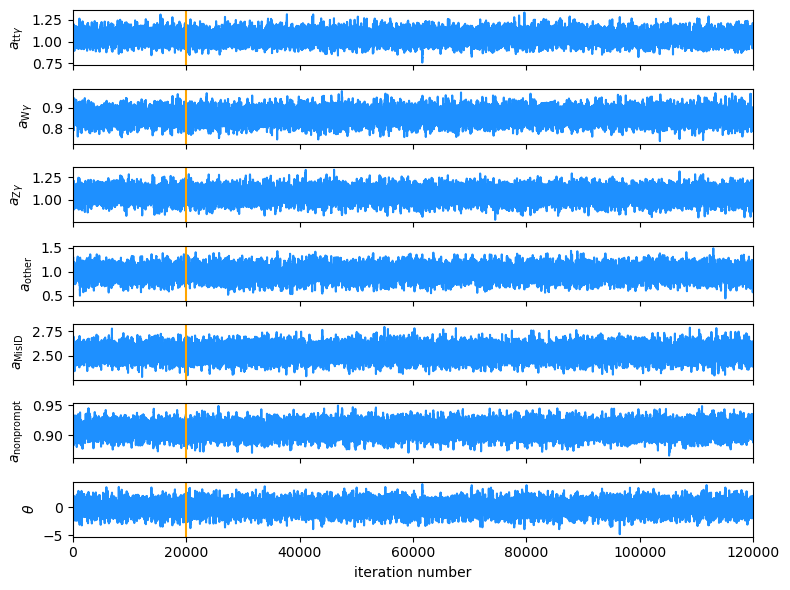

In [6]:
# Show trace plots
parname_latex = [r'$a_{\mathrm{tt}\gamma}$', r'$a_{\mathrm{W}\gamma}$', r'$a_{\mathrm{Z}\gamma}$', r'$a_{\text{other}}$', r'$a_{\text{MisID}}$', r'$a_{\text{nonprompt}}$', r'$\theta$']
fig, axes = plt.subplots(sharex=True, nrows=7, figsize=(8,6))
plt.xlim(0, 120000)
for i, (ax, label) in enumerate(zip(axes, parname_latex)):
    ax.plot(samples[:, i], color="dodgerblue")
    ax.axvline(20000, color="orange")
    ax.set_ylabel(label)
axes[-1].set_xlabel("iteration number")
fig.tight_layout()
plt.savefig("./Plots/baye_trace.png")
plt.show()


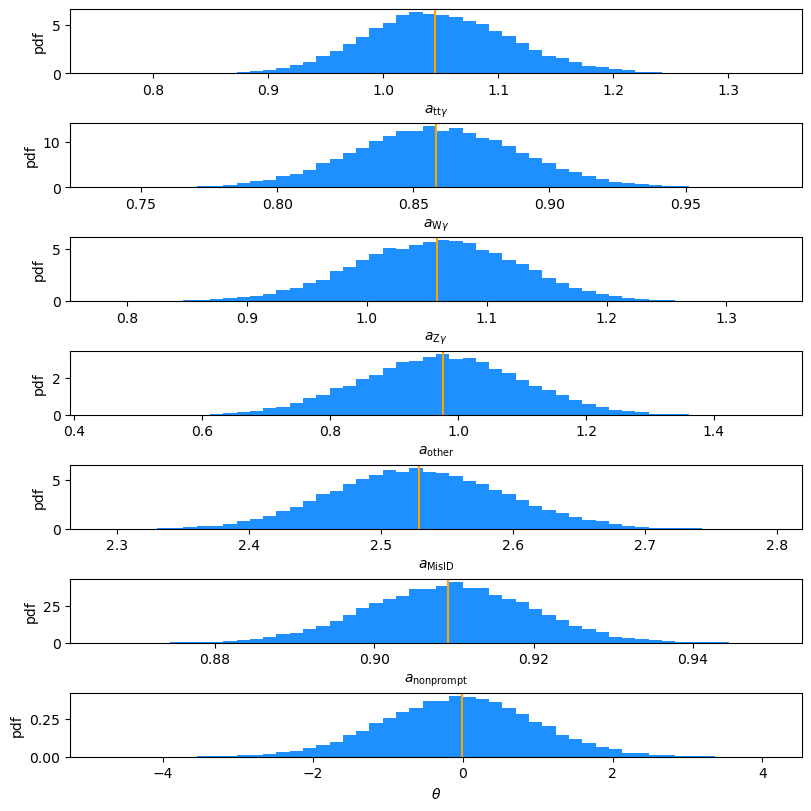

In [7]:
# Show marginal distributions
fig, axes = plt.subplots(nrows=7, figsize=(8,8))
for i, (ax, label, sim) in enumerate(zip(axes, parname_latex, bf_params)):
    ax.hist(samples[20000:, i], bins=50, density=True, color="dodgerblue")
    ax.set(xlabel=label, ylabel="pdf")
    ax.axvline(sim, color="orange")
fig.tight_layout(pad=0.3)
plt.savefig("./Plots/baye_marginal.png")
plt.show()


In [19]:
th_sigma = 15.10
sigma_samples = mu_samples * th_sigma

sigma_med = np.percentile(sigma_samples, 50)
sigma_lo = np.percentile(sigma_samples, 15.87)
sigma_hi = np.percentile(sigma_samples, 84.13)

print(f"Bayesian sigma = {sigma_med:.3f} +{sigma_hi - sigma_med:.3f} -{sigma_med - sigma_lo:.3f}")

low, high = np.quantile(sigma_samples, [0.025, 0.975])
print(f"95% Central Credible Interval = {low:.3f} - {high:.3f}")

Bayesian sigma = 15.807 +0.993 -0.916
95% Central Credible Interval = 14.068 - 17.828


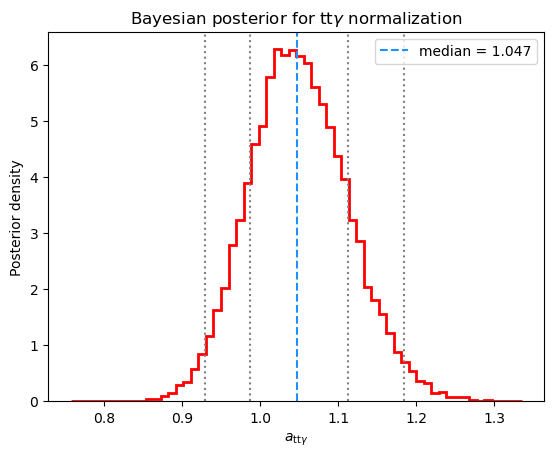

In [9]:
plt.clf()
plt.hist(mu_samples, bins=60, density=True, histtype="step", linewidth=2, color = 'red')
plt.axvline(mu_med, color="dodgerblue", linestyle="--", label=rf"median = {mu_med:.3f}")
plt.axvline(mu_lo, color="gray", linestyle=":")
plt.axvline(mu_hi, color="gray", linestyle=":")
plt.axvline(mu_lo95, color="gray", linestyle=":")
plt.axvline(mu_hi95, color="gray", linestyle=":")
plt.xlabel(r"$a_{\mathrm{tt}\gamma}$")
plt.ylabel("Posterior density")
plt.title(r"Bayesian posterior for $\mathrm{tt}\gamma$ normalization")
plt.legend()
plt.savefig("./Plots/baye_posterior.png")
plt.show()


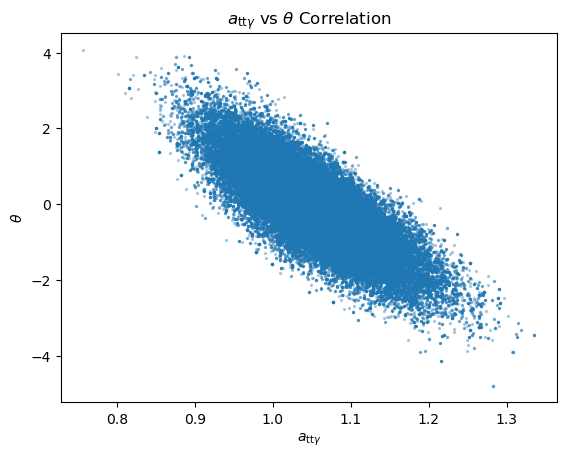

In [10]:
plt.scatter(samples[:,0], samples[:,6], s=2, alpha=0.3)
plt.xlabel(r"$a_{\mathrm{tt}\gamma}$")
plt.ylabel(r"$\theta$")
plt.title(r'$a_{\mathrm{tt}\gamma}$ vs $\theta$ Correlation')
plt.savefig("./Plots/baye_corr.png")
plt.show()


In [11]:
groupingCategory = {
    "NonPrompt": [3j, 4j],
    "MisID": [2j],
    "Prompt": [1j],
}

groupingFineCategory = {
    "Genuine Photon": [1j],
    "Misidentified Electron": [2j],
    "Hadronic Photon": [3j],
    "Hadronic Fake": [4j],
}

groupingMCDatasets = {
    "ZG": [
        "ZGamma_01J_5f_lowMass",
    ],
    "WG": [
        "WGamma",
    ],
    "other": [
        "TTbarPowheg_Dilepton",
        "TTbarPowheg_Semilept",
        "TTbarPowheg_Hadronic",
        "W2jets",
        "W3jets",
        "W4jets",
        "DYjetsM50",
        "ST_s_channel",
        "ST_tW_channel",
        "ST_tbarW_channel",
        "ST_tbar_channel",
        "ST_t_channel",
        "TTWtoLNu",
        "TTWtoQQ",
        "TTZtoLL",
        "GJets_HT200To400",
        "GJets_HT400To600",
        "GJets_HT600ToInf",
        "ZZ",
        "WZ",
        "WW",
        "TGJets",
    ],
    "ttgamma": [
        "TTGamma_Dilepton",
        "TTGamma_SingleLept",
        "TTGamma_Hadronic",
    ],
}

colors = [
    "#e15759",  # ttgamma
    "#59a14f",  # WG
    "#4e79a7",  # ZG
    "#bab0ab",  # other
    "#b07aa1",  # MisID
    "#76b7b2",  # NonPrompt
]

In [12]:
def bayesian_posterior_predictions(
    comps_nominal,
    samples,
    kappa_ttg=1.05,
    n_draws=2000,
    seed=123,
    include_poisson=False,
):
    """
    Build posterior predictive summaries for one histogram.

    Parameters
    ----------
    comps_nominal : dict[str, Hist]
        Output of extract_components(...) BEFORE applying scale factors.
        Should contain keys:
        ["ttgamma", "WG", "ZG", "other", "MisID", "NonPrompt"]

    samples : np.ndarray, shape (nsamples, 7)
        Posterior samples from the Bayesian pipeline.

    kappa_ttg : float
        lnN factor used in the nuisance model.

    n_draws : int
        Number of posterior draws to use for the predictive band.

    seed : int
        RNG seed.

    include_poisson : bool
        If False, bands reflect parameter uncertainty only.
        If True, also include Poisson fluctuations in generated counts.

    Returns
    -------
    result : dict
        Contains posterior summaries for each component and total.
    """
    rng = np.random.default_rng(seed)

    nsamp = len(samples)
    draw_idx = rng.choice(nsamp, size=min(n_draws, nsamp), replace=False)

    # nominal component arrays
    nominal_vals = {name: np.asarray(h.values(), dtype=float) for name, h in comps_nominal.items()}
    first_hist = next(iter(comps_nominal.values()))
    bin_edges = first_hist.axes[0].edges
    nbins = len(bin_edges) - 1

    comp_names = ["ttgamma", "WG", "ZG", "other", "MisID", "NonPrompt"]

    # store sampled predictions
    comp_draws = {name: [] for name in comp_names}
    total_draws = []

    for i in draw_idx:
        a_ttg, a_wg, a_zg, a_other, a_misid, a_np, theta = samples[i]

        pred = {
            "ttgamma":   a_ttg * (kappa_ttg ** theta) * nominal_vals["ttgamma"],
            "WG":        a_wg * nominal_vals["WG"],
            "ZG":        a_zg * nominal_vals["ZG"],
            "other":     a_other * nominal_vals["other"],
            "MisID":     a_misid * nominal_vals["MisID"],
            "NonPrompt": a_np * nominal_vals["NonPrompt"],
        }

        total = np.zeros(nbins, dtype=float)
        for name in comp_names:
            total += pred[name]
            comp_draws[name].append(pred[name])

        if include_poisson:
            total = rng.poisson(total)

        total_draws.append(total)

    # convert to arrays
    for name in comp_names:
        comp_draws[name] = np.asarray(comp_draws[name])
    total_draws = np.asarray(total_draws)

    # posterior summaries
    comp_median = {name: np.percentile(comp_draws[name], 50, axis=0) for name in comp_names}
    comp_lo     = {name: np.percentile(comp_draws[name], 16, axis=0) for name in comp_names}
    comp_hi     = {name: np.percentile(comp_draws[name], 84, axis=0) for name in comp_names}

    total_median = np.percentile(total_draws, 50, axis=0)
    total_lo     = np.percentile(total_draws, 16, axis=0)
    total_hi     = np.percentile(total_draws, 84, axis=0)

    return {
        "bin_edges": bin_edges,
        "comp_median": comp_median,
        "comp_lo": comp_lo,
        "comp_hi": comp_hi,
        "total_median": total_median,
        "total_lo": total_lo,
        "total_hi": total_hi,
        "total_draws": total_draws,
    }

In [13]:
s = hist.tag.Slicer()

# 1) First reproduce the grouped MC object from your script
outputMC_grouped = {
    process: accumulate(outputMC[ds] for ds in datasets)
    for process, datasets in groupingMCDatasets.items()
}
outputDataHist = accumulate([histo for key, histo in outputData.items()])

def getHisto(name):
    return DictToHist(
        {process: histos[name] for process, histos in outputMC_grouped.items()},
        name="dataset"
    )

# 2) Helper to build the grouped histogram exactly as in your workflow
def build_grouped_hist(name, lepFlavor=sum, rebin_spec=None, axis_range=None):
    """
    name: histogram name, e.g. 'photon_chIso', 'M3', 'photon_lepton_mass_3j0t'
    lepFlavor: sum, 'electron', or 'muon'
    rebin_spec: dict like {"M3": s[50j:550j+1:hist.rebin(4)]}
    axis_range: tuple like ("M3", 50, 550)
    """
    h = getHisto(name)

    # sum/select lepton flavor if that axis exists
    axis_names = [ax.name for ax in h.axes]
    if "lepFlavor" in axis_names:
        h = h[{"lepFlavor": lepFlavor}]

    # collapse fine category -> Prompt / MisID / NonPrompt
    if "category" in axis_names or "category" in [ax.name for ax in h.axes]:
        h = GroupBy(h, "category", "category", groupingCategory)

    # apply optional rebinning/slicing
    if rebin_spec is not None:
        h = h[rebin_spec]

    # apply optional range restriction
    if axis_range is not None:
        axis_name, xmin, xmax = axis_range
        h = SetRangeHist(h, axis_name, xmin, xmax)

    return h

# 3) Extract the six mutually exclusive fit components
def extract_components(h, systematic="nominal", method="frequentist"):
    comps = {
        "ttgamma":   h[{"dataset": "ttgamma", "category": "Prompt",    "systematic": systematic}],
        "WG":        h[{"dataset": "WG",      "category": "Prompt",    "systematic": systematic}],
        "ZG":        h[{"dataset": "ZG",      "category": "Prompt",    "systematic": systematic}],
        "other":     h[{"dataset": "other",   "category": "Prompt",    "systematic": systematic}],
        "MisID":     h[{"dataset": sum,       "category": "MisID",     "systematic": systematic}],
        "NonPrompt": h[{"dataset": sum,       "category": "NonPrompt", "systematic": systematic}],
    }
    # apply scale factors
    for name, hist in comps.items():
        if method == "frequentist":
            sf = bf_params_freq[name]
        else:
            sf = 1.
        comps[name] = hist * sf
    return comps

# 5) Obtain numpy arrays from histograms (for both dict of hists and just hists)
def components_to_numpy(comps):
    """
    Convert dict of Hist objects into numpy arrays.

    Returns:
        yields_dict   : dict of np arrays (counts per bin)
        errors_dict   : dict of np arrays (stat uncertainties)
        bin_edges     : bin edges
    """

    yields_dict = {}
    errors_dict = {}

    # grab binning from the first histogram
    first_hist = next(iter(comps.values()))
    bin_edges = first_hist.axes[0].edges

    for name, h in comps.items():
        vals = h.values()
        vars_ = h.variances()

        yields_dict[name] = np.array(vals)
        errors_dict[name] = np.sqrt(vars_) if vars_ is not None else np.sqrt(vals)

    return yields_dict, errors_dict, bin_edges

def datahist_to_numpy(h):
    """
    Convert a Hist data histogram into numpy arrays.

    Returns
    -------
    data_vals : np.ndarray
        Observed counts per bin
    data_err  : np.ndarray
        Statistical uncertainties
    bin_edges : np.ndarray
        Bin edges
    """

    data_vals = np.array(h.values())
    variances = h.variances()

    if variances is not None:
        data_err = np.sqrt(variances)
    else:
        # Poisson assumption
        data_err = np.sqrt(data_vals)

    bin_edges = h.axes[0].edges

    return data_vals, data_err, bin_edges

/usr/local/lib/python3.10/site-packages/hist/basehist.py:480: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


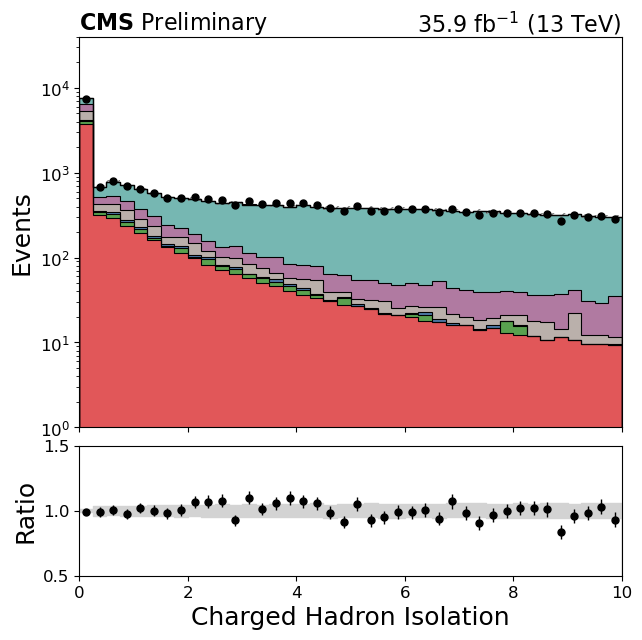

In [14]:
h_chIso = build_grouped_hist(
    "photon_chIso",
    lepFlavor=sum,
    rebin_spec={"chIso": s[:: hist.rebin(5)]},
    axis_range=("chIso", 0, 10),
)

comps_chIso = extract_components(
    h_chIso,
    systematic="nominal",
    method="bayesian",   # this leaves them unscaled in your current function
)
hComp_chIso = DictToHist(comps_chIso, name="dataset")

hData_chIso = outputDataHist["photon_chIso"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_chIso_tmp = hData_chIso[{"chIso": s[:: hist.rebin(5)]}]
hData_chIso = SetRangeHist(hData_chIso_tmp, "chIso", 0, 10)

# data arrays
data_vals_chIso, data_err_chIso, bin_edges_chIso = datahist_to_numpy(hData_chIso)

# nominal components (unscaled)
comps_chIso_nominal = extract_components(
    h_chIso,
    systematic="nominal",
    method="bayesian",
)

# build posterior predictive summaries from posterior samples
pred_chIso = bayesian_posterior_predictions(
    comps_nominal=comps_chIso_nominal,
    samples=samples,          # from your Bayesian pipeline
    kappa_ttg=1.05,           # same value used in the fit
    n_draws=2000,
    seed=123,
    include_poisson=True,    # parameter uncertainty band
)

# plot
fig, ax, rax = plot_bayesian_postfit(
    pred_summary=pred_chIso,
    data_vals=data_vals_chIso,
    data_err=data_err_chIso,
    bin_edges=bin_edges_chIso,
    logY=True,
    leg="right",
    xRange=[0, 10],
    title=r"Charged Hadron Isolation",
    colors=colors,
    displeg=False,
)
plt.savefig("./Plots/baye_chIso.png")


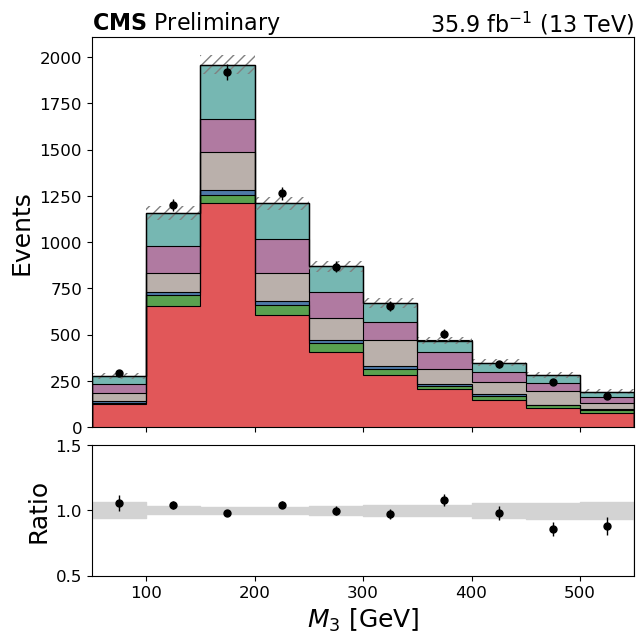

In [15]:
h_m3 = build_grouped_hist(
    "M3",
    lepFlavor=sum,
    rebin_spec={"M3": s[50j:550j+1:hist.rebin(4)]},
    axis_range=("M3", 50, 550),
)

comps_m3 = extract_components(h_m3, systematic="nominal", method="bayesian")
hComp_m3 = DictToHist(comps_m3, name="dataset")

hData_m3 = outputDataHist["M3"][{"lepFlavor": sum, "category": sum, "systematic": sum}]
hData_m3_tmp = hData_m3[{"M3": s[50j:550j+1:hist.rebin(4)]}]
hData_m3 = SetRangeHist(hData_m3_tmp, "M3", 50, 550)

# data arrays
data_vals_m3, data_err_m3, bin_edges_m3 = datahist_to_numpy(hData_m3)

# nominal components (unscaled)
comps_m3_nominal = extract_components(
    h_m3,
    systematic="nominal",
    method="bayesian",
)

# build posterior predictive summaries from posterior samples
pred_m3 = bayesian_posterior_predictions(
    comps_nominal=comps_m3_nominal,
    samples=samples,          # from your Bayesian pipeline
    kappa_ttg=1.05,           # same value used in the fit
    n_draws=2000,
    seed=123,
    include_poisson=True,    # parameter uncertainty band
)

# plot
fig, ax, rax = plot_bayesian_postfit(
    pred_summary=pred_m3,
    data_vals=data_vals_m3,
    data_err=data_err_m3,
    bin_edges=bin_edges_m3,
    logY=False,
    xRange=[50, 550],
    title=r"$M_3$ [GeV]",
    leg='right',
    colors=colors,
    displeg=False,
)
plt.savefig("./Plots/baye_m3.png")

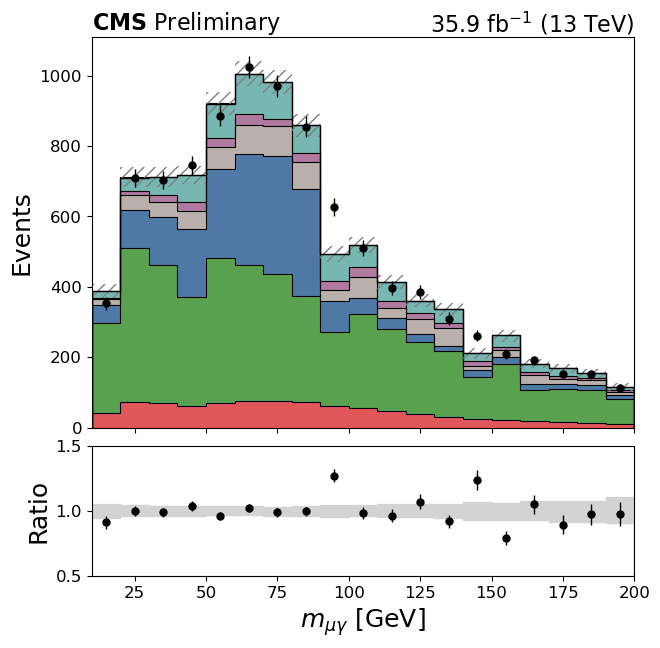

In [16]:
h_mass_mu = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="muon",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)
comps_mass_mu = extract_components(h_mass_mu, systematic="nominal", method="bayesian")
hComp_mass_mu = DictToHist(comps_mass_mu, name="dataset")

hData_mass_mu = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "muon", "category": sum, "systematic": sum}]
hData_mass_mu_tmp = hData_mass_mu[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_mu = SetRangeHist(hData_mass_mu_tmp, "mass", 10, 200)

# data arrays
data_vals_mass_mu, data_err_mass_mu, bin_edges_mass_mu = datahist_to_numpy(hData_mass_mu)

# nominal components (unscaled)
comps_mass_mu_nominal = extract_components(
    h_mass_mu,
    systematic="nominal",
    method="bayesian",
)

# build posterior predictive summaries from posterior samples
pred_mass_mu = bayesian_posterior_predictions(
    comps_nominal=comps_mass_mu_nominal,
    samples=samples,          # from your Bayesian pipeline
    kappa_ttg=1.05,           # same value used in the fit
    n_draws=2000,
    seed=123,
    include_poisson=True,    # parameter uncertainty band
)

# plot
fig, ax, rax = plot_bayesian_postfit(
    pred_summary=pred_mass_mu,
    data_vals=data_vals_mass_mu,
    data_err=data_err_mass_mu,
    bin_edges=bin_edges_mass_mu,
    title=r"$m_{\mu \gamma}$ [GeV]",
    xRange=[10,200],
    logY=False,
    leg="right",
    colors=colors,
    displeg=False,
)
plt.savefig("./Plots/baye_mass_mu.png")


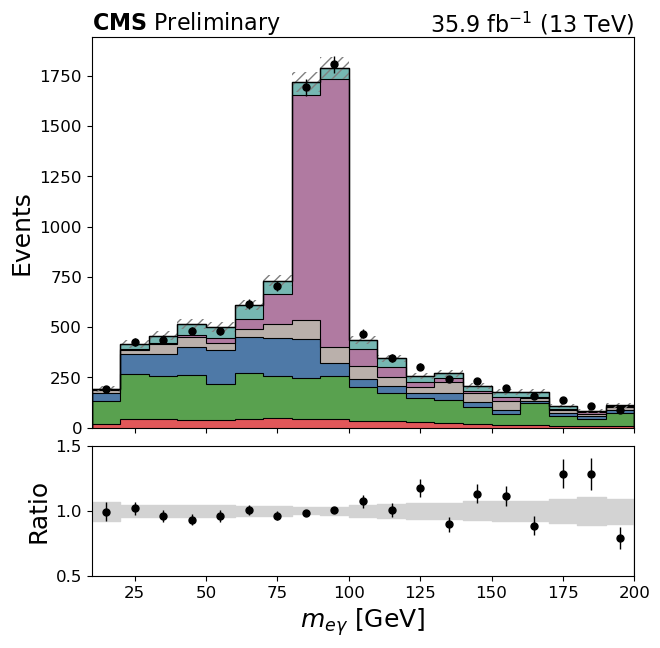

In [17]:
h_mass_el = build_grouped_hist(
    "photon_lepton_mass_3j0t",
    lepFlavor="electron",
    rebin_spec={"mass": s[10j:200j+1:hist.rebin(10)]},
    axis_range=("mass", 10, 200),
)
comps_mass_el = extract_components(h_mass_el, systematic="nominal", method="bayesian")
hComp_mass_el = DictToHist(comps_mass_el, name="dataset")

hData_mass_el = outputDataHist["photon_lepton_mass_3j0t"][{"lepFlavor": "electron", "category": sum, "systematic": sum}]
hData_mass_el_tmp = hData_mass_el[{"mass": s[10j:200j+1:hist.rebin(10)]}]
hData_mass_el = SetRangeHist(hData_mass_el_tmp, "mass", 10, 200)

# data arrays
data_vals_mass_el, data_err_mass_el, bin_edges_mass_el = datahist_to_numpy(hData_mass_el)

# nominal components (unscaled)
comps_mass_el_nominal = extract_components(
    h_mass_el,
    systematic="nominal",
    method="bayesian",
)

# build posterior predictive summaries from posterior samples
pred_mass_el = bayesian_posterior_predictions(
    comps_nominal=comps_mass_el_nominal,
    samples=samples,          # from your Bayesian pipeline
    kappa_ttg=1.05,           # same value used in the fit
    n_draws=2000,
    seed=123,
    include_poisson=True,    # parameter uncertainty band
)

# plot
fig, ax, rax = plot_bayesian_postfit(
    pred_summary=pred_mass_el,
    data_vals=data_vals_mass_el,
    data_err=data_err_mass_el,
    bin_edges=bin_edges_mass_el,
    title=r"$m_{e \gamma}$ [GeV]",
    xRange=[10,200],
    logY=False,
    leg="right",
    colors=colors,
    displeg=False,
)
plt.savefig("./Plots/baye_mass_el.png")
